### Higher-order phase-based encoding in triplet neural interactions

This notebook reproduces **Figure 2** by simulating three coupled Kuramoto oscillators under three graph structures (chain, collider, visual cortex) and quantifying how pairwise phase differences encode coupling strength through redundant and synergistic information.

**Workflow:**
1. Configure the environment and imports.
2. Define figure-layout helpers.
3. Set up simulation parameters and graph structures.
4. Simulate trial-wise coupled dynamics and compute time-frequency representations.
5. Estimate mutual information and decompose it into redundancy and synergy (PID).
6. Assemble and export the multi-panel figure.

#### 1) Environment setup

Add the project root to the Python path so local modules under `src/` (e.g. `src.models.simulate_kuramoto`) are importable from this notebook.

In [1]:
import os

In [2]:
import sys

sys.path.insert(1, os.path.join("/", *os.getcwd().split("/")[:-1]))

#### 2) Imports and dependencies

Scientific Python stack (NumPy, SciPy, Matplotlib), MNE time-frequency tools, HOI information-theoretic estimators, JAX for vectorised computation, and the local Kuramoto simulator.

In [3]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from frites.core import copnorm_nd
from hoi.core import get_mi
from mne.time_frequency.tfr import tfr_array_morlet, tfr_array_multitaper
from tqdm import tqdm

from src.models import simulate_kuramoto

/home/INT/brovelli.a/.local/lib/python3.10/site-packages/tqdm-4.67.1-py3.10.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### 3) Figure helper functions

`make_figure` assembles the 3-row × 3-column layout (circuit cartoon | redundancy heatmap | synergy heatmap) and handles all axis styling and colorbars.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg


def make_figure(
    redundancy_data: list,  # [row_A, row_C, row_E], each a 2D array (n_freqs, n_times)
    synergy_data: list,
    freqs: np.ndarray,      # frequency axis (shared across rows)
    cartoon_paths: list,    # [path_A, path_C, path_E]
    panel_labels=('A', 'B', 'C', 'D', 'E', 'F'),
    cmap='turbo',
    figsize=(12, 14),
    bg_color='white',
):
    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor(bg_color)

    outer = gridspec.GridSpec(3, 1, figure=fig,
                              hspace=0.45, top=0.96, bottom=0.06,
                              left=0.05, right=0.97)

    row_labels = [(panel_labels[0], panel_labels[1]),
                  (panel_labels[2], panel_labels[3]),
                  (panel_labels[4], panel_labels[5])]

    for row_idx in range(3):
        gs = gridspec.GridSpecFromSubplotSpec(
            1, 3, subplot_spec=outer[row_idx],
            width_ratios=[1, 1.6, 1.6], wspace=0.35
        )

        diag_label, heat_label = row_labels[row_idx]
        rd = redundancy_data[row_idx]
        sd = synergy_data[row_idx]
        # shared colour scale across redundancy and synergy panels
        vmax = np.max(np.concatenate((rd.flatten(), sd.flatten())))

        # --- Cartoon panel ---
        ax_diag = fig.add_subplot(gs[0])
        ax_diag.set_facecolor(bg_color)
        for sp in ax_diag.spines.values():
            sp.set_visible(False)
        ax_diag.set_xticks([])
        ax_diag.set_yticks([])
        ax_diag.text(0.02, 1.4, diag_label, transform=ax_diag.transAxes,
                     color='black', fontsize=13, fontweight='bold', va='top')
        img = mpimg.imread(cartoon_paths[row_idx])
        ax_diag.imshow(img, aspect='equal')

        # --- Redundancy heatmap ---
        ax_r = fig.add_subplot(gs[1])
        im_r = ax_r.imshow(
            rd,
            aspect='auto',
            origin='lower',
            cmap=cmap,
            extent=[-0.5, 1, freqs[0], freqs[-1]],
            vmin=0,
            vmax=vmax,
        )
        ax_r.text(0.02, 1.02, heat_label, transform=ax_r.transAxes,
                  color='black', fontsize=13, fontweight='bold', va='bottom')
        if row_idx == 0:
            ax_r.set_title('Redundancy', color='black', fontsize=10, pad=4)
        _style_heatmap_ax(fig, ax_r, im_r,
                          ylabel=True, xlabel=(row_idx == 2), bg=bg_color)

        # --- Synergy heatmap ---
        ax_s = fig.add_subplot(gs[2])
        im_s = ax_s.imshow(
            sd,
            aspect='auto',
            origin='lower',
            cmap=cmap,
            extent=[-0.5, 1, freqs[0], freqs[-1]],
            vmin=0,
            vmax=vmax,
        )
        if row_idx == 0:
            ax_s.set_title('Synergy', color='black', fontsize=10, pad=4)
        _style_heatmap_ax(fig, ax_s, im_s,
                          ylabel=False, xlabel=(row_idx == 2), bg=bg_color)


def _style_heatmap_ax(fig, ax, im, ylabel, xlabel, bg):
    ax.set_facecolor(bg)
    ax.tick_params(colors='black', labelsize=8, which='both',
                   bottom=True, left=True,
                   labelbottom=xlabel, labelleft=ylabel)
    for sp in ax.spines.values():
        sp.set_edgecolor('black')

    if ylabel:
        ax.set_ylabel('Frequency [Hz]', color='black', fontsize=9)

    if xlabel:
        ax.set_xlabel('Time [s]', color='black', fontsize=9)

    cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.ax.tick_params(colors='black', labelsize=8)
    cbar.outline.set_edgecolor('black')
    cbar.set_label(r'$I(\theta_1, \theta_2; Y)$ [bits]',
                   color='black', fontsize=8, rotation=270, labelpad=15)


#### 4) Simulation parameters and graph structures

Three directed network topologies are studied:

| Structure | Connectivity | Expected HOI |
|-----------|-------------|--------------|
| **Chain** A→B→C | Linear propagation | Redundancy (Δθ₁ and Δθ₂ carry the same information about Y) |
| **Collider** A→C←B | Common-target | Synergy (Y is encoded only in the joint phase Δθ₁, Δθ₂) |
| **Visual** (FLN) | Recurrent V1–V2–V4 | Mixed redundancy and synergy driven by anatomical weights |

The FLN (fraction of labelled neurons) matrix and inter-areal distances are taken from Markov et al. (2014).

In [7]:
structures = ["chain", "collider", "visual"]
synergies = []
redundancies = []

#### 5) Kuramoto simulation and time-frequency analysis

For each graph structure, simulate `ntrials = 200` trials of three coupled Kuramoto oscillators (ω = 2π × 40 Hz, β = 1.5). The coupling strength follows a Gaussian temporal profile (0–0.4 s) whose peak amplitude increases linearly from 1 to 100 across trials, providing a graded task-related variable Y.

Complex Morlet wavelet coefficients (20–60 Hz, n_cycles = f_c / 2) are then used to extract the three pairwise phase differences:

- Δθ₁ = ∠(W₁ · W₂*) — between nodes 1 and 2
- Δθ₂ = ∠(W₂ · W₃*) — between nodes 2 and 3
- Δθ₃ = ∠(W₁ · W₃*) — between nodes 1 and 3

**Memory note:** `W` (200 trials × 3 nodes × 50 freqs × 1500 times, complex128) is ~720 MB. Cross-spectra are computed and deleted one at a time to keep peak memory below ~1.5 GB. All phase arrays are stored as `float32` to halve the footprint of `sim_data`.

In [ ]:
dt = 0.001  # s
fs = 1 / dt
f = 40      # Hz, carrier frequency for all oscillators
beta = 1.5  # noise variance (same for all nodes)

sim_data = {}

for structure in structures:

    if structure == "chain":
        # A[j, i] = 1 means node i drives node j  (i→j)
        A = np.array([[0, 1, 0], [0, 0, 1], [0, 0, 0]]).T
        D = np.zeros_like(A)
    elif structure == "collider":
        A = np.array([[0, 0, 1], [0, 0, 1], [0, 0, 0]]).T
        D = np.zeros_like(A)
    elif structure == "visual":
        SC_data = np.load("../interareal/markov2014.npy", allow_pickle=True).item()
        A = SC_data["FLN"][np.ix_([0, 1, 2], [0, 1, 2])]
        D = SC_data["Distances"] * 0 * 1e-3 / 3.5  # * 0: conduction delays disabled
        D /= dt
        D = D[np.ix_([0, 1, 2], [0, 1, 2])]

    g = 5
    ntrials = 250
    time = np.arange(-0.5, 1, 1 / fs)
    T = time.shape[0]

    # Gaussian width = 8 carrier cycles, centred in the stimulus window
    s = 8 / (2 * np.pi * f)
    time_start = 0
    time_end = 0.4
    timestim = time[(time > time_start) & (time < time_end)] - (time_end - time_start) / 2
    ind = np.where((time > time_start) & (time < time_end))[0]
    gaussian = np.exp(-(timestim**2) / (2 * s**2))
    coupling = np.zeros_like(time)
    coupling[ind] = gaussian

    # Y: coupling amplitude increases linearly across trials (task-related variable)
    CS = np.linspace(1, 100, ntrials)
    seeds = np.random.randint(0, 100000, ntrials)

    data = []
    for trial in tqdm(range(ntrials)):
        data += [
            simulate_kuramoto(
                g * A, D, coupling * CS[trial], f, fs, beta, T, seed=seeds[trial], decim=1
            )
        ]

    # KOP (Kuramoto order parameter) — kept for diagnostics, freed immediately
    h = scipy.signal.hilbert(np.stack(data).real, axis=2)
    kop = np.abs(h.mean(1)).mean(0)
    del h

    freqs = np.linspace(20, 60, 50)
    W = tfr_array_morlet(
        data, fs / 1, freqs, n_cycles=freqs / 2, decim=1, output="complex", verbose=None,
    )
    del data

    # Coherence between nodes 1 and 3
    Sxy = (W[:, 0] * np.conj(W[:, 2])).mean(0)
    Sxx = (W[:, 0] * np.conj(W[:, 0])).mean(0)
    Syy = (W[:, 2] * np.conj(W[:, 2])).mean(0)
    coh = np.abs(Sxy) ** 2 / (Sxx * Syy)
    del Sxy, Sxx, Syy

    # Phase differences — one cross-spectrum at a time to keep peak memory ≈ W + one_e (~960 MB)
    e = W[:, 0] * np.conj(W[:, 1])
    dphi1 = np.abs((np.angle(e) + np.pi) % (2 * np.pi) - np.pi).astype(np.float32)
    del e

    e = W[:, 1] * np.conj(W[:, 2])
    dphi2 = np.abs((np.angle(e) + np.pi) % (2 * np.pi) - np.pi).astype(np.float32)
    del e

    e = W[:, 0] * np.conj(W[:, 2])
    dphi3 = np.abs((np.angle(e) + np.pi) % (2 * np.pi) - np.pi).astype(np.float32)
    del e, W

    # Broadcast trial labels to (ntrials, n_freqs, n_times); float32 halves sim_data footprint
    labels = np.tile(
        np.expand_dims(np.linspace(0, 100, ntrials), (1, 2)), (dphi1.shape[1], dphi1.shape[2])
    ).astype(np.float32)

    sim_data[structure] = dict(
        dphi1=dphi1, dphi2=dphi2, dphi3=dphi3, labels=labels, coh=coh,
    )


#### 6) Mutual information and PID analysis

Mutual information between each phase-difference variable and the trial-wise coupling strength Y is estimated using the **Gaussian-copula MI** estimator (GC-MI), which is invariant to monotone marginal transformations.

The **Partial Information Decomposition (PID)** then separates the joint MI I(Δθ₁, Δθ₂; Y) into:

- **Redundancy**: min(I(Δθ₁; Y), I(Δθ₂; Y)) — information independently available from each phase difference.
- **Synergy**: I(Δθ₁, Δθ₂; Y) − max(I(Δθ₁; Y), I(Δθ₂; Y)) — additional information available only from the joint variable.

The MI function is vmapped over the **time axis** only; a Python loop over frequencies limits peak JAX/XLA memory to one frequency band at a time. Structure-specific phase pairs follow the graph logic:

| Structure | Variables used |
|-----------|---------------|
| Chain | Δθ₁ (1→2), Δθ₂ (2→3) |
| Collider | Δθ₂ (2→3), Δθ₃ (1→3) |
| Visual | Δθ₁, Δθ₂, Δθ₃ (all three pairs) |

In [ ]:
mi_fcn = get_mi("gc")

# vmap over time axis only; frequency loop in compute_mi_tf keeps JAX peak memory low
mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))
mi_fcn_time_frequency = jax.vmap(mi_fcn_time, in_axes=(2, 2, None, None))

for structure in structures:
    dphi1  = sim_data[structure]["dphi1"]
    dphi2  = sim_data[structure]["dphi2"]
    dphi3  = sim_data[structure]["dphi3"]
    labels = sim_data[structure]["labels"]

    # [None] adds the features dim → (1, ntrials, n_freqs, n_times) expected by mi_fcn
    l = labels[None]

    if structure == "chain":
        dphi   = jnp.stack((dphi1, dphi2))       # (2, ntrials, n_freqs, n_times)
        mi1_   = mi_fcn_time_frequency(dphi1[None], l, False, True)
        mi2_   = mi_fcn_time_frequency(dphi2[None], l, False, True)
        mi123_ = mi_fcn_time_frequency(dphi,        l, False, True)
        red = np.minimum(mi1_, mi2_)
        syn = mi123_ - np.maximum(mi1_, mi2_)

    elif structure == "collider":
        dphi   = jnp.stack((dphi2, dphi3))
        mi1_   = mi_fcn_time_frequency(dphi2[None], l, False, True)
        mi2_   = mi_fcn_time_frequency(dphi3[None], l, False, True)
        mi123_ = mi_fcn_time_frequency(dphi,        l, False, True)
        red = np.minimum(mi1_, mi2_)
        syn = mi123_ - np.maximum(mi1_, mi2_)

    else:  # visual — three-way PID
        dphi   = jnp.stack((dphi1, dphi2, dphi3))
        mi1_   = mi_fcn_time_frequency(dphi1[None], l, False, True)
        mi2_   = mi_fcn_time_frequency(dphi2[None], l, False, True)
        mi3_   = mi_fcn_time_frequency(dphi3[None], l, False, True)
        mi123_ = mi_fcn_time_frequency(dphi,        l, False, True)
        red = np.minimum(np.minimum(mi1_, mi2_), mi3_)
        syn = mi123_ - np.maximum(np.maximum(mi1_, mi2_), mi3_)

    redundancies.append(red)
    synergies.append(syn)


#### 7) Figure assembly and export

Build the 3-row panel figure with `make_figure` and save to `../figures/Figure2.pdf`. Each row corresponds to one graph structure; columns show the circuit cartoon, the redundancy time-frequency map, and the synergy time-frequency map.

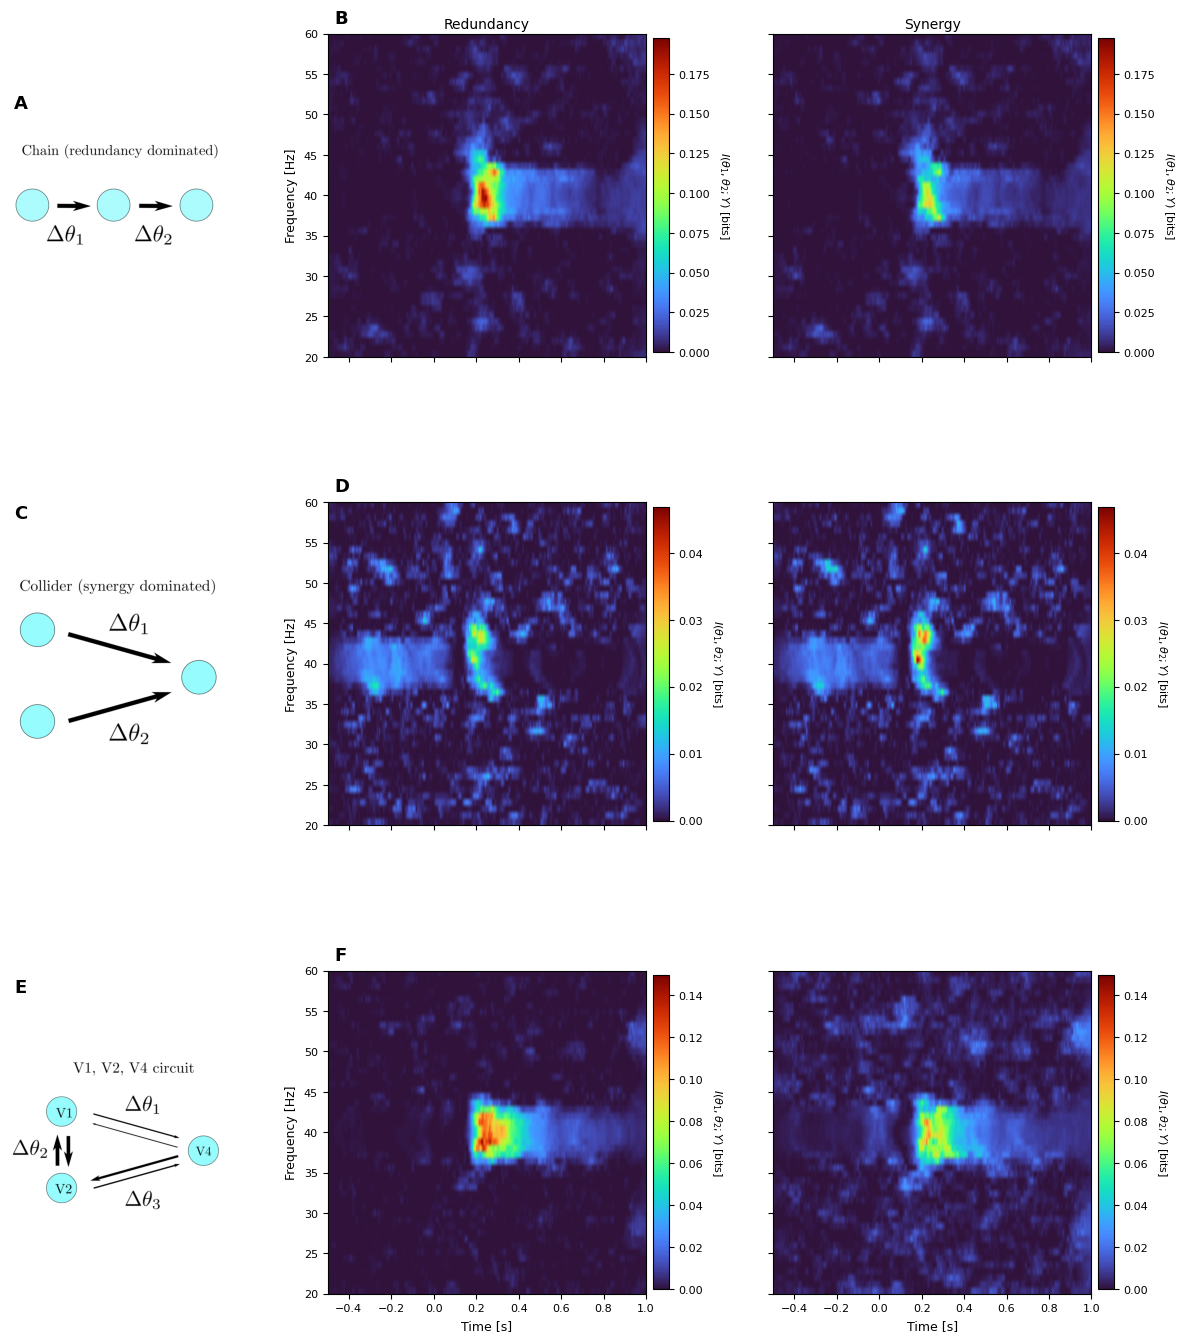

In [25]:
make_figure(
    redundancies,
    synergies,
    freqs,
    ["../figures/3chain_cartoon.png",
     "../figures/3collider_cartoon.png",
     "../figures/3circuit_cartoon.png",],
    panel_labels=('A','B','C','D','E','F'),
    cmap='turbo',
    figsize=(12, 14),
    bg_color='white',
)

Figure 2: Phase-based encoding in higher-order neural interactions. Simulation of three Kuramoto
oscillators (Eq. 13) with the same parameters for all nodes (ω = 2π 40 Hz; η = 1.5), coupled via unidirectional
edges. The coupling strength among nodes was transiently modulated from 0.1 to 0.3s using a Gaussian
profile with coupling amplitude increasing from 1 to 100 across trials (n = 1000). (A) Redundant encoding
was simulated using a chain structure. Phase differences between nodes ∆θ1 and ∆θ2 were derived from
the Wavelet coefficients of the nodes’ time-series (Eq. 10; ncycles = fc/ 2; for fc ∈ [20, 60] Hz). (C) Synergistic
encoding was simulated using a collider structure. (E) Simulation of a three-nodes Kuramoto network
structured in a recurrent connectivity. Structural connectivity strengths are proportional to their anatomical
connectivity measured via retrograde tracing (FLN; Markov et al. (2013)) between three hypothetical visual
cortical areas V1, V2 and V4 circuit. The effective connectivity between nodes i and j is given by Cij · FLNij,
and the arrows representing edges are scaled accordingly. (B, D and F) Time–frequency representation of
redundant (left panel) and synergistic (right panel) information carried by phase differences ∆θ1 and ∆θ2
about the task-related variable Y, computed using the PID approach (Eqs. 6 and 7).